# Top-NMF: Appendix 1

# Import Libraries

In [18]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from sklearn.decomposition._nmf import _initialize_nmf
from tqdm.notebook import tqdm

from TopNMF import *

device = 'cpu'

# Generate Ichimatsu Patterns

(40, 81)


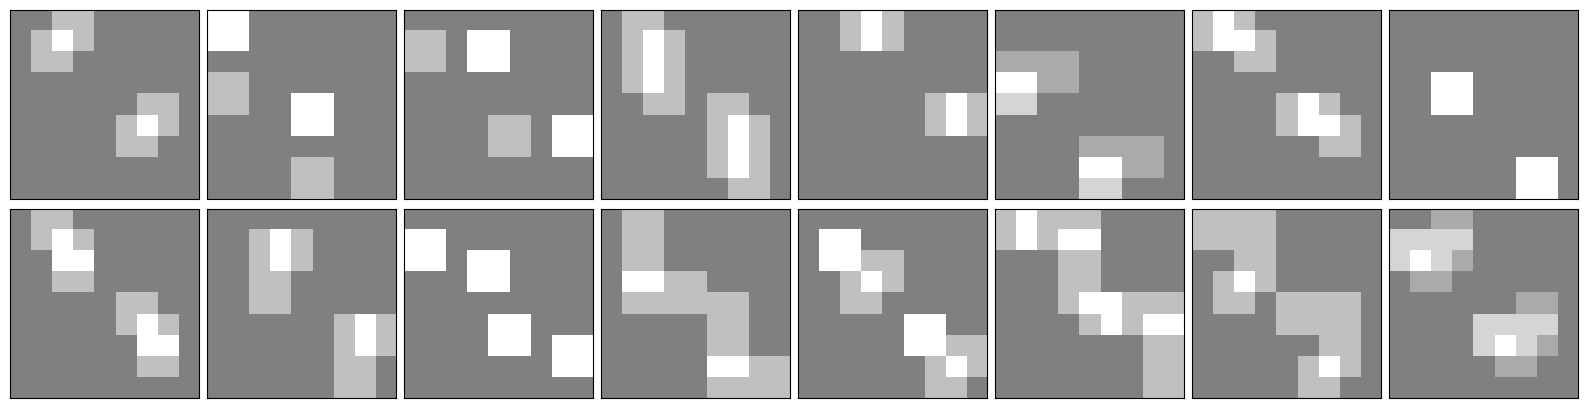

In [19]:
image_shape = (9, 9)

pat=np.zeros((6,6))
pat[0:2,0:2]=1
pat[4:6,4:6]=1
X = create_ichimatsu_pattern(num_samples=40,image_shape = image_shape,pat=pat,pat_step=1,min_pat=2,max_pat=5, seed=42)
X /= np.max(X, axis=(1, 2), keepdims=True)
plot_gallery(X, n_row=2, n_col=8)

n_samples = X.shape[0]
data_dims = X.shape[1:]
n_features = X[0].size
X = X.reshape(n_samples, -1)
print(X.shape)

# Run Top-NMF

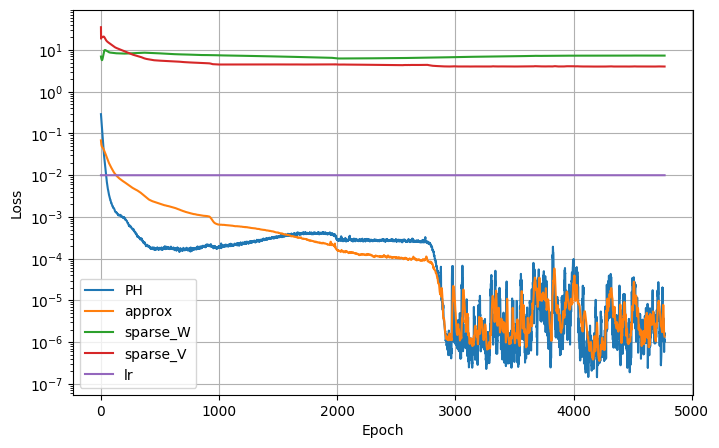

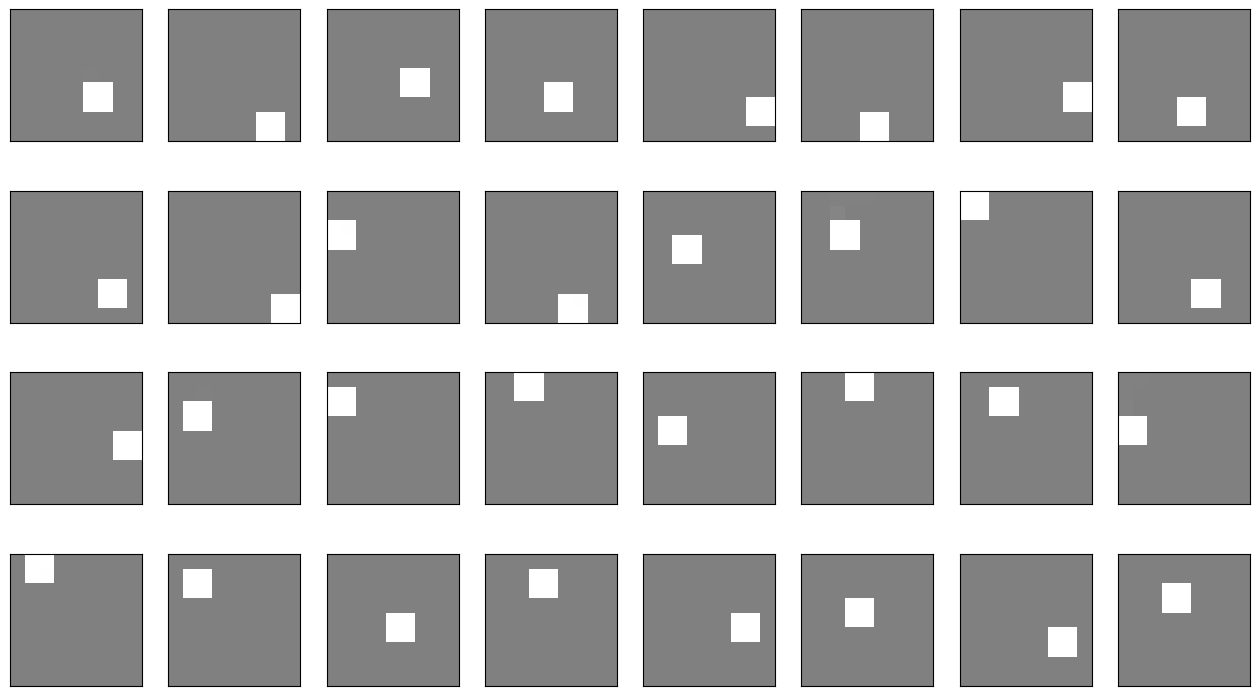

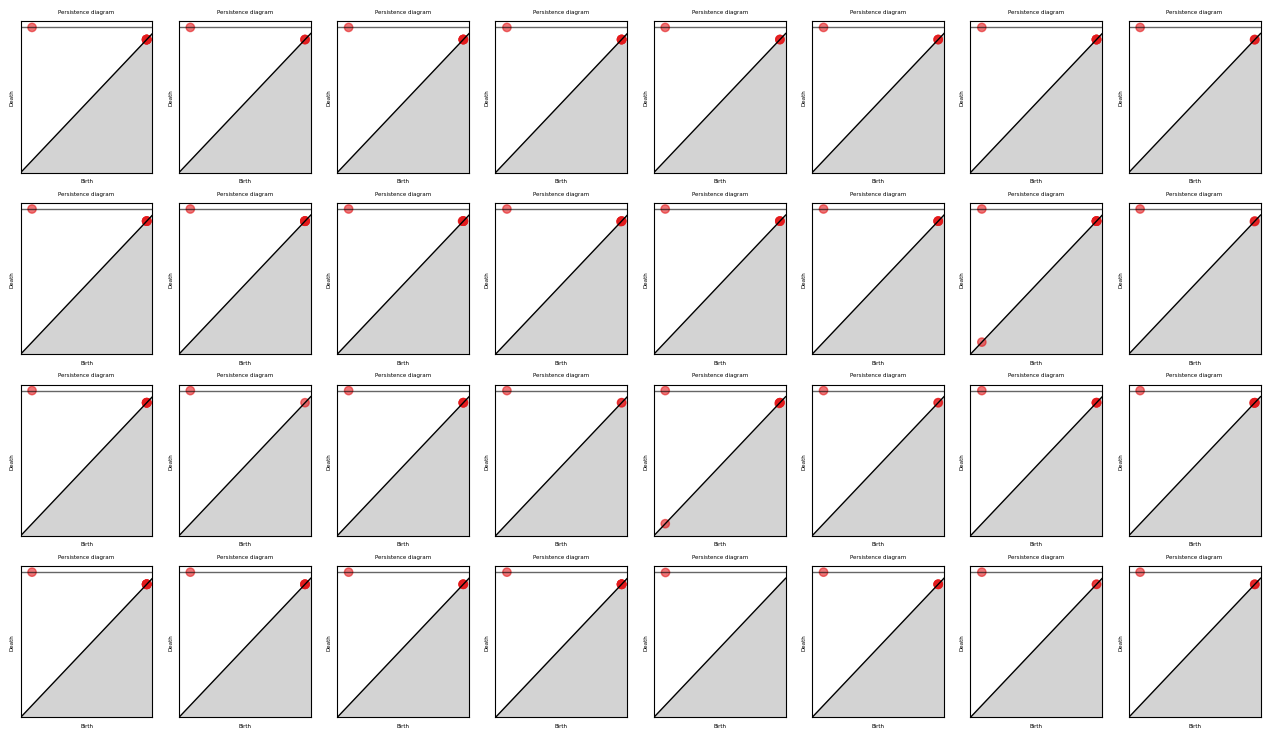

  0%|          | 0/5000 [00:00<?, ?it/s]

In [20]:
cubical_complex = CubicalComplex(
    superlevel=True,
    dim=len(image_shape),
    mode='V'
)


target_diagrams = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]


model = TopologicalNMF(
    n_components=32,
    device='cpu',
    complex=cubical_complex,
    ph_loss_fn=target_diagram_loss,
    data_shape=image_shape,
    use_embedding=False,
    random_state = 42
)

model.fit(
    X,
    n_iterations=5000,
    lr=0.01,
    lambda_top=0.6,
    weight_decay=0.1,
    PH_dims=[0, 1],
    start_epoch_topological=0,
    show_plots=['loss', 'basis', 'PH'],
    disp_interval=10,
    verbose=True,
    target_diagrams = target_diagrams,
    init_method = 'nndsvdar',
    plot_grid = (4,8),
    superlevel=True, 
    PHmode='V'
)
plt.close('all')